In [ ]:
## Data Conversion
Machine Learning Tidak dapat menerima **NULL Value** maupun **String/Test**
- NULL Value / Missing Value, Harus dihandle ==> Drop atau Fill
- String/Kategorik Harus kita ubah menjadi Numerik

### Data Conversion Untuk Kebutuhan Machine Learning (ML Needs)
## Encoding
- Proses Mengubah/Mengkonversi Data kategorikal/String menjadi Numerik
- Meskipun nantinya sudah berubah menjadi Numerik, Selalu Handle data sebagai Kategorikal (Tidak menggunakan Operasi Math)

## Secara General Encoding dibagi menjadi 2 Jenis

### Label Encoding
- Mengubah Data kategorikal menjadi **ANgka Berurutan** (Numerik)
- Hanya untuk data yg bertipe *Ordinal** dan atau **Binary**
- Ordinal ==> Kategori data yg memiliki Urutan/Tingkatan/Rank
- Urutan/tingkatan antar kategori harus sama
- Binary ==> Data bertipe Nominal, tetapi hanya ada 2 Jenis kategori ==> Data memiliki Unique Value hanya 2
- Harus memiliki Urutan data secara benar

### One Hot Encoding
- Mengubah data kategorikal Menjadi Kolom - Kolom baru, Jumlah kolom sesuai dg Jumlah data unique
- Digunakan untuk mengkonversi data bertipe Nominal/Kategorikal yg **TIDAK** memiliki Urutan/Tingkatan
- One Hot Encoding dapat digunakan untuk Ordinal maupun Binary tapi akan berefek pada Komputasi (Proses Training Model akan membutuhkan waktu lama)
- Proses Encoding :
    Misal kolom Kota memiliki data unik : Jakarta, Bandung, Surabaya. Akan di encode menjadi :
    |Kota  |                Jakarta   |  Bandung   |   Surabaya   |
    Jakarta                    1      |    0       |      0 
    Jakarta                    1      |    0       |      0 
    Bandung                    0      |    1       |      0
    Surabaya                   0     |    0      |      1

## Data COnversion untuk Improvement Machine Learning

## Binning
- Mengubah Continous Numerik menjadi Kategorikal
- Bertujuan agar model ML lebih mudah membaca/mempelajari Pola/Pattern yg ada
- Jumlah kategorikal berdasarkan analisis data - DOmain/Bisnis Knowledge
- COntoh proses Binning
==> Pengelompokkan Usia ==> dari numerik menjadi kategorikal ==> Child - Teenager - Adult - Old
==> Pengelompokkan Harga ==> dari Murah - Mahal
- Pengelompokkan bisa dilakukan dg COding manual ataupun pandas function

## Recategorize
- Mengubah Kategorikal lama/Yg sudah ada, menjadi kategorikal baru yg jumlahnya lebih sedikit
- Bertujuan agar model ML lebih mudah membaca/mempelajari Pola/Pattern yg ada
- Efisiensi proses Komputasi, karena jumlah kolom yg diencode lebih sedikit
- Biasanya digunakan untuk Kolom bertipe Nominal (Tidak punya urutan) dan jumlah unique-nya sangat banyak
- Re-categorize dilakukan berdasarkan analisa dan Domain/Bisnis Knowledge
- Contoh Proses ReCategorize
    - Bulan dikelompokkan kembali menjadi Kuartal/Season
    - Hari dikelompokkan menjadi WeekEnd dan Weekdays
    - Negara dikelompokkan menjadi Benua
    - Kota dikelompokkan menjadi Provinsi
    - Kota dikelompokkan menjadi ==> Kolom baru ==> Jakarta yg berisi Yes dan No ==> Jika hanya jakarta yg memiliki Nilai/Perbedaan signifikan dibanding yg lain
    - Kota dikelompokkan menjadi ==> Jakarta, Bandung, Others ==> Jika jakarta dan bandung yg signifikan

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [75]:
df = pd.read_csv('cereal.csv', index_col = 0)
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,FDA_25,3,1.0,0.75,34.384843


<img src='cereal.png'>

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 100% Bran to Wheaties Honey Gold
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mfr       77 non-null     object 
 1   type      77 non-null     object 
 2   calories  77 non-null     int64  
 3   protein   77 non-null     int64  
 4   fat       77 non-null     int64  
 5   sodium    77 non-null     int64  
 6   fiber     77 non-null     float64
 7   carbo     76 non-null     float64
 8   sugars    76 non-null     float64
 9   potass    75 non-null     float64
 10  vitamins  77 non-null     object 
 11  shelf     77 non-null     int64  
 12  weight    77 non-null     float64
 13  cups      77 non-null     float64
 14  rating    77 non-null     float64
dtypes: float64(7), int64(5), object(3)
memory usage: 9.6+ KB


In [77]:
df.dtypes

mfr          object
type         object
calories      int64
protein       int64
fat           int64
sodium        int64
fiber       float64
carbo       float64
sugars      float64
potass      float64
vitamins     object
shelf         int64
weight      float64
cups        float64
rating      float64
dtype: object

In [78]:
df.isna().sum()

mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       1
sugars      1
potass      2
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
calories,77.0,106.883117,19.484119,50.000000,100.000000,110.000000,110.000000,160.000000
protein,77.0,2.545455,1.094790,1.000000,2.000000,3.000000,3.000000,6.000000
fat,77.0,1.012987,1.006473,0.000000,0.000000,1.000000,2.000000,5.000000
sodium,77.0,159.675325,83.832295,0.000000,130.000000,180.000000,210.000000,320.000000
fiber,77.0,2.151948,2.383364,0.000000,1.000000,2.000000,3.000000,14.000000
carbo,76.0,14.802632,3.907326,5.000000,12.000000,14.500000,17.000000,23.000000
sugars,76.0,7.026316,4.378656,0.000000,3.000000,7.000000,11.000000,15.000000
potass,75.0,98.666667,70.410636,15.000000,42.500000,90.000000,120.000000,330.000000
shelf,77.0,2.207792,0.832524,1.000000,1.000000,2.000000,3.000000,3.000000
weight,77.0,1.029610,0.150477,0.500000,1.000000,1.000000,1.000000,1.500000


In [80]:
df.describe(include='O')

,mfr,type,vitamins
count,77,77,77
unique,7,2,3
top,K,C,FDA_25
freq,23,74,63


In [81]:
cerealDesc = []
for i in df.columns:
    cerealDesc.append([
    i,
    df[i].dtypes,
    df[i].isna().sum(),
    round((df[i].isna().sum()/len(df))*100, 2),
    df[i].nunique(),
    df[i].drop_duplicates().sample(2).values])

In [82]:
pd.DataFrame(data = cerealDesc,
            columns=['features',
                    'DataType',
                    'Null',
                    'NullPercentage',
                    'Unique',
                    'Sample'])

,features,DataType,Null,NullPercentage,Unique,Sample
0,mfr,object,0,0.0,7,"[N, Q]"
1,type,object,0,0.0,2,"[H, C]"
2,calories,int64,0,0.0,11,"[70, 100]"
3,protein,int64,0,0.0,6,"[3, 4]"
4,fat,int64,0,0.0,5,"[1, 3]"
5,sodium,int64,0,0.0,27,"[135, 160]"
6,fiber,float64,0,0.0,13,"[1.0, 2.5]"
7,carbo,float64,1,1.3,21,"[nan, 23.0]"
8,sugars,float64,1,1.3,16,"[12.0, 11.0]"
9,potass,float64,2,2.6,35,"[170.0, 45.0]"


In [83]:
df['mfr'].value_counts()

mfr
K    23
G    22
P     9
Q     8
R     8
N     6
A     1
Name: count, dtype: int64

In [84]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,FDA_25,3,1.0,0.75,34.384843


In [85]:
df.dropna().head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10.0,70.0,FDA_25,1,1.0,0.75,29.509541


In [86]:
df.head(7)

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,NaN,FDA_25,3,1.0,0.75,34.384843
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10.0,70.0,FDA_25,1,1.0,0.75,29.509541
Apple Jacks,K,C,110,2,0,125,1.0,11.0,14.0,30.0,FDA_25,2,1.0,1.00,33.174094


In [87]:
df.fillna("====Random====").head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,====Random====,FDA_25,3,1.0,0.75,34.384843


In [88]:
df.fillna(method='bfill').head(7)

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,70.0,FDA_25,3,1.0,0.75,34.384843
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10.0,70.0,FDA_25,1,1.0,0.75,29.509541
Apple Jacks,K,C,110,2,0,125,1.0,11.0,14.0,30.0,FDA_25,2,1.0,1.00,33.174094


In [89]:
df.fillna(method='ffill').head(7)

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,330.0,FDA_25,3,1.0,0.75,34.384843
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10.0,70.0,FDA_25,1,1.0,0.75,29.509541
Apple Jacks,K,C,110,2,0,125,1.0,11.0,14.0,30.0,FDA_25,2,1.0,1.00,33.174094


In [90]:
df.mean(numeric_only=True).round(2)

calories    106.88
protein       2.55
fat           1.01
sodium      159.68
fiber         2.15
carbo        14.80
sugars        7.03
potass       98.67
shelf         2.21
weight        1.03
cups          0.82
rating       42.67
dtype: float64

In [91]:
df.isna().sum()

mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       1
sugars      1
potass      2
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

In [92]:
df.fillna(df.mean(numeric_only=True).round(2)).head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843


In [93]:
isi = {
'carbo' : "Ini Cargo",
'sugars' : df['sugars'].mean(),
'potass' : df['potass'].median()}

In [94]:
df.fillna(isi).head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.0,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.0,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.0,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.0,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,90.0,FDA_25,3,1.0,0.75,34.384843


In [95]:
df['potass'].median()

90.0

In [96]:
df.fillna(df.mean(numeric_only=True).round(2), inplace=True)

In [97]:
df.isna().sum()

mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64

In [98]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843


In [99]:
df['type'].value_counts()

type
C    74
H     3
Name: count, dtype: int64

In [100]:
df['vitamins'].value_counts()

vitamins
FDA_25     63
FDA_0       8
FDA_100     6
Name: count, dtype: int64

In [101]:
df['shelf'].value_counts()

shelf
3    36
2    21
1    20
Name: count, dtype: int64

In [102]:
### Encoding

In [103]:
set(sns.get_dataset_names())

{'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic'}

In [104]:
## Label Encoding

In [105]:
df['type'].value_counts()

type
C    74
H     3
Name: count, dtype: int64

In [106]:
df['type_encode'] = df['type'].map({'C' : 0, 'H' : 1})

In [107]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,type_encode
name,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973,0
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679,0
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505,0
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912,0
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843,0


## Akan langsung mereplace isi dari Kolom type menjadi numerikal
df['type'] = df['type'].map({'C' : 0, 'H' : 1})

In [108]:
df['shelf'].value_counts()

shelf
3    36
2    21
1    20
Name: count, dtype: int64

In [109]:
df['shelf_str'] = df['shelf'].map({1: 'Lower', 2 : 'Middle', 3 : 'Top'})

In [110]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,type_encode,shelf_str
name,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973,0,Top
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679,0,Top
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505,0,Top
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912,0,Top
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843,0,Top


## Re-Categorize
- Melakukan Re-categorize menggunakan fungsi manual (Kita membuat fungsi sendiri baik menggunakan Def function maupun lambda)
- Menerapkan/Mengoperasikan suatu fungsi/fungsi yg kita buat ke setiap elemen dari dataframe menggunakan fungsi **.apply(Function)**

In [111]:
def to_mg(x):
    return x * 1000

In [112]:
df['fiber_mg'] = df['fiber'].apply(to_mg)

In [113]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg
name,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973,0,Top,10000.0
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679,0,Top,2000.0
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505,0,Top,9000.0
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912,0,Top,14000.0
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843,0,Top,1000.0


In [114]:
df['mfr'].value_counts()

mfr
K    23
G    22
P     9
Q     8
R     8
N     6
A     1
Name: count, dtype: int64

In [115]:
## Buat Function untuk Recategorize
def re_cat(x):
    if x == 'K':
        return 'Yes'
    else:
        return 'No'

In [116]:
df['Kellogs'] = df['mfr'].apply(re_cat)

In [117]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs
name,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973,0,Top,10000.0,No
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679,0,Top,2000.0,No
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505,0,Top,9000.0,Yes
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912,0,Top,14000.0,Yes
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843,0,Top,1000.0,No


In [118]:
## Buat Function untuk Recategorize
def re_cat2(x):
    if x == 'K':
        return x
    elif x == 'G':
        return x
    else:
        return 'Others'

In [119]:
df['mfr_recat'] = df['mfr'].apply(re_cat2)

In [120]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,mfr_recat
name,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,FDA_25,3,1.0,0.33,68.402973,0,Top,10000.0,No,Others
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,FDA_0,3,1.0,1.00,33.983679,0,Top,2000.0,No,Others
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,FDA_25,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,K
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,FDA_25,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,K
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,FDA_25,3,1.0,0.75,34.384843,0,Top,1000.0,No,Others


In [121]:
## One Hot Encoding - Dummy Variabel

In [122]:
df['mfr'].unique()

array(['N', 'Q', 'K', 'R', 'G', 'P', 'A'], dtype=object)

In [123]:
df['vitamins'].unique()

array(['FDA_25', 'FDA_0', 'FDA_100'], dtype=object)

In [124]:
pd.options.display.max_columns=99

In [125]:
pd.get_dummies(df, columns=['vitamins'], dtype='int32', prefix_sep='__').head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,mfr_recat,vitamins__FDA_0,vitamins__FDA_100,vitamins__FDA_25
name,,,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,3,1.0,0.33,68.402973,0,Top,10000.0,No,Others,0,0,1
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,3,1.0,1.00,33.983679,0,Top,2000.0,No,Others,1,0,0
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,K,0,0,1
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,K,0,0,1
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,3,1.0,0.75,34.384843,0,Top,1000.0,No,Others,0,0,1


In [126]:
pd.get_dummies(df, columns=['vitamins', 'mfr_recat'], dtype='int32', prefix_sep='__').head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,vitamins__FDA_0,vitamins__FDA_100,vitamins__FDA_25,mfr_recat__G,mfr_recat__K,mfr_recat__Others
name,,,,,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,3,1.0,0.33,68.402973,0,Top,10000.0,No,0,0,1,0,0,1
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,3,1.0,1.00,33.983679,0,Top,2000.0,No,1,0,0,0,0,1
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,0,0,1,0,1,0
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,0,0,1,0,1,0
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,3,1.0,0.75,34.384843,0,Top,1000.0,No,0,0,1,0,0,1


In [127]:
df = pd.get_dummies(df, columns=['vitamins'], dtype='int32')

## Binning
continous Numerikal - Kategorikal


In [128]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,mfr_recat,vitamins_FDA_0,vitamins_FDA_100,vitamins_FDA_25
name,,,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,3,1.0,0.33,68.402973,0,Top,10000.0,No,Others,0,0,1
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,3,1.0,1.00,33.983679,0,Top,2000.0,No,Others,1,0,0
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,K,0,0,1
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,K,0,0,1
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,3,1.0,0.75,34.384843,0,Top,1000.0,No,Others,0,0,1


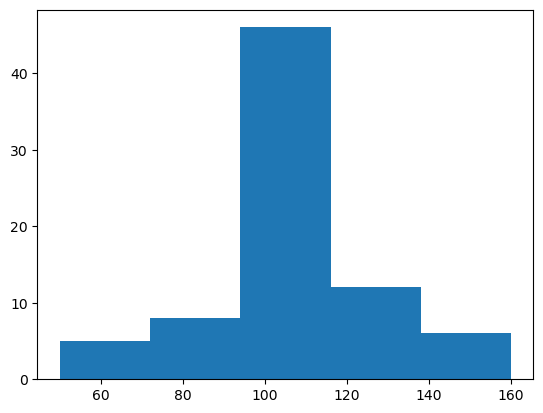

In [130]:
df['calories'].hist(bins=5)
plt.grid(False)
plt.show()

In [131]:
df['calories_bin'] = pd.cut(df['calories'], bins=5, labels=[0,1,2,3,4])

In [132]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,mfr_recat,vitamins_FDA_0,vitamins_FDA_100,vitamins_FDA_25,calories_bin
name,,,,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,3,1.0,0.33,68.402973,0,Top,10000.0,No,Others,0,0,1,0
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,3,1.0,1.00,33.983679,0,Top,2000.0,No,Others,1,0,0,3
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,K,0,0,1,0
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,K,0,0,1,0
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,3,1.0,0.75,34.384843,0,Top,1000.0,No,Others,0,0,1,2


In [133]:
df['rating'].unique()

array([68.402973, 33.983679, 59.425505, 93.704912, 34.384843, 29.509541,
       33.174094, 37.038562, 49.120253, 53.313813, 18.042851, 50.764999,
       19.823573, 40.400208, 22.736446, 41.445019, 45.863324, 35.782791,
       22.396513, 40.448772, 64.533816, 46.895644, 36.176196, 44.330856,
       32.207582, 31.435973, 58.345141, 40.917047, 41.015492, 28.025765,
       35.252444, 23.804043, 52.076897, 53.371007, 45.811716, 21.871292,
       31.072217, 28.742414, 36.523683, 36.471512, 39.241114, 45.328074,
       26.734515, 54.850917, 37.136863, 34.139765, 30.313351, 40.105965,
       29.924285, 40.69232 , 59.642837, 30.450843, 37.840594, 41.50354 ,
       60.756112, 63.005645, 49.511874, 50.828392, 39.259197, 39.7034  ,
       55.333142, 41.998933, 40.560159, 68.235885, 74.472949, 72.801787,
       31.230054, 53.131324, 59.363993, 38.839746, 28.592785, 46.658844,
       39.106174, 27.753301, 49.787445, 51.592193, 36.187559])

In [134]:
bin_rating = [0, 50, 75, df['rating'].max()] ## membuat 3 interval ==> 0-50, 50-75, 75 - max

In [135]:
label = ['C', 'B', 'A']

In [136]:
df['Rate'] = pd.cut(df['rating'], bins=bin_rating, labels=label)

In [137]:
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,shelf,weight,cups,rating,type_encode,shelf_str,fiber_mg,Kellogs,mfr_recat,vitamins_FDA_0,vitamins_FDA_100,vitamins_FDA_25,calories_bin,Rate
name,,,,,,,,,,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6.0,280.00,3,1.0,0.33,68.402973,0,Top,10000.0,No,Others,0,0,1,0,B
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8.0,135.00,3,1.0,1.00,33.983679,0,Top,2000.0,No,Others,1,0,0,3,C
All-Bran,K,C,70,4,1,260,9.0,7.0,5.0,320.00,3,1.0,0.33,59.425505,0,Top,9000.0,Yes,K,0,0,1,0,B
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0.0,330.00,3,1.0,0.50,93.704912,0,Top,14000.0,Yes,K,0,0,1,0,A
Almond Delight,R,C,110,2,2,200,1.0,14.0,8.0,98.67,3,1.0,0.75,34.384843,0,Top,1000.0,No,Others,0,0,1,2,C
